# Computer Vision Assignment 2

## Imports

In [68]:
from __future__ import print_function

# Core deep learning framework
import tensorflow as tf
import keras

# Keras model and layer imports
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D, Rescaling, BatchNormalization

# Optimisers
from keras.optimizers import RMSprop, Adam

# Plotting and numerical operations
import matplotlib.pyplot as plt
import numpy as np

## Configuration

In [69]:
# Training parameters
batch_size = 12
epochs = 8

# Image dimensions
img_width = 128
img_height = 128
img_channels = 3

# Controls whether the model is trained or loaded from disk
fit = True

# Dataset paths
train_dir = 'data/chest_xray/train'
test_dir  = 'data/chest_xray/test'

## Load Datasets

In [70]:
# Load training and validation datasets from directory
# 80% training, 20% validation split
train_ds, val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    seed=123,
    validation_split=0.2,
    subset='both',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    labels='inferred',
    shuffle=True)

# Load test dataset
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    seed=None,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    labels='inferred',
    shuffle=True)

# Infer class names from subfolder names
class_names = train_ds.class_names
num_classes = len(class_names)
print('Class Names:', class_names)
print('Number of Classes:', num_classes)

Found 5419 files belonging to 3 classes.
Using 4336 files for training.
Using 1083 files for validation.
Found 437 files belonging to 3 classes.
Class Names: ['BACTERIAL', 'NORMAL', 'VIRAL']
Number of Classes: 3


## Visualise Sample Images

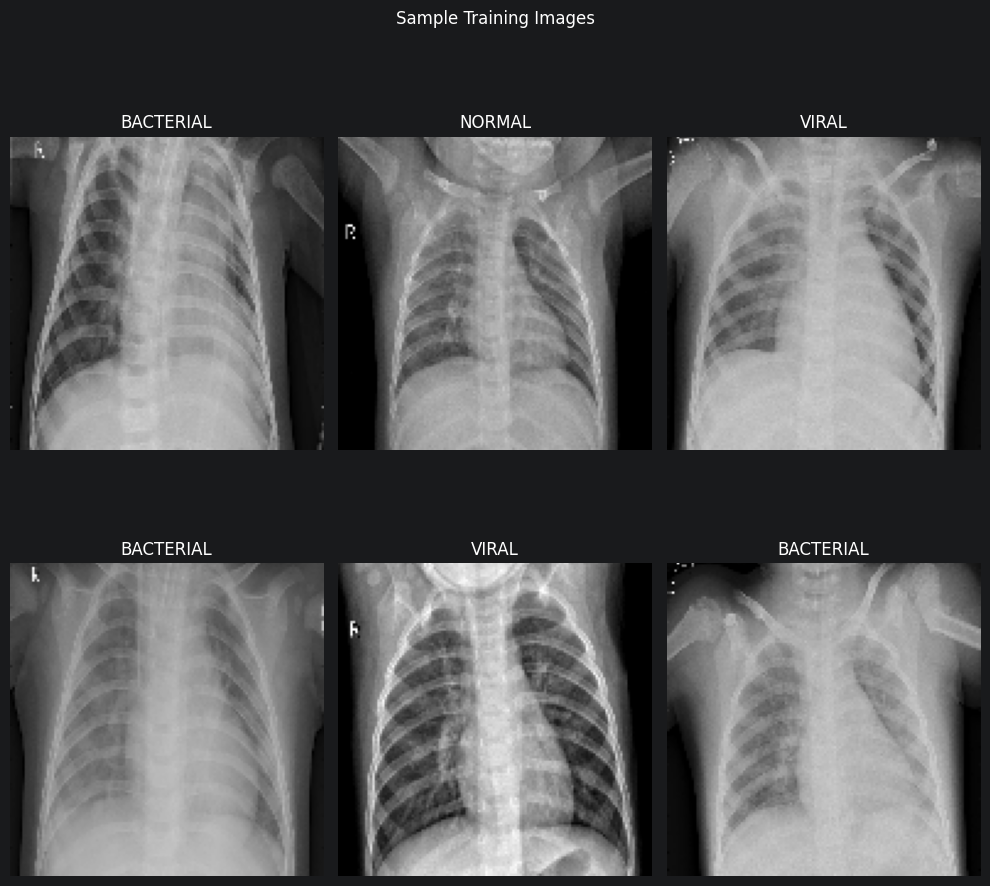

In [71]:
# Display a sample of images from the training dataset
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(2):
    for i in range(6):
        ax = plt.subplot(2, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i].numpy()])
        plt.axis("off")
plt.suptitle("Sample Training Images")
plt.tight_layout()
plt.savefig('results/plots/step1_sample_images.png')
plt.show()

## Build the Model

In [72]:
# Build the baseline CNN model
model = tf.keras.models.Sequential([
    # Define input shape explicitly
    tf.keras.Input(shape=(img_height, img_width, img_channels)),
    # Normalise pixel values from [0, 255] to [0, 1]
    Rescaling(1.0/255),
    # Convolutional layers for feature extraction
    Conv2D(16, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    # Flatten multidimensional output into a single dimension
    Flatten(),
    # Fully connected layers for classification
    Dense(512, activation='relu'),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')
])

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=Adam(),
    metrics=['accuracy']
)

model.summary()

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_11 (Rescaling)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 126, 126, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_33 (MaxPooling2D) │ (None, 63, 63, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 61, 61, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_34 (MaxPooling2D) │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_35 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,227,651 (12.31 MB)

 Trainable params: 3,227,651 (12.31 MB)

 Non-trainable params: 0 (0.00 B)

## Train the Model

In [73]:
import time

# Save the best model during training
save_callback = tf.keras.callbacks.ModelCheckpoint(
    'results/baseline.keras',
    save_freq='epoch',
    save_best_only=True
)

# Record training time
start_time = time.time()

if fit:
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        callbacks=[save_callback],
        epochs=epochs
    )
else:
    # Load saved model instead of retraining
    model = tf.keras.models.load_model('results/baseline.keras')

elapsed = time.time() - start_time
print(f'Training time: {elapsed/60:.1f} minutes')

Epoch 1/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.7138 - loss: 0.6636 - val_accuracy: 0.7544 - val_loss: 0.5721
Epoch 2/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.7834 - loss: 0.5166 - val_accuracy: 0.7701 - val_loss: 0.5453
Epoch 3/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.8003 - loss: 0.4758 - val_accuracy: 0.7719 - val_loss: 0.5280
Epoch 4/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.8116 - loss: 0.4387 - val_accuracy: 0.7719 - val_loss: 0.5422
Epoch 5/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8270 - loss: 0.4116 - val_accuracy: 0.7664 - val_loss: 0.5500
Epoch 6/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.8420 - loss: 0.3673 - val_accuracy: 0.7719 - val_loss: 0.5543
Epoch 7/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.8556 - loss: 0.3347 - val_accuracy: 0.7719 - val_loss: 0.5759
Epoch 8/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.8782 - loss: 0.2838 - val_accuracy: 0.

## Evaluate Model on Test Set

In [74]:
# Evaluate the trained model on the test set
score = model.evaluate(test_ds)
print(f'Test Loss:     {score[0]:.4f}')
print(f'Test Accuracy: {score[1]*100:.2f}%')

37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7643 - loss: 0.6482
Test Loss:     0.6482
Test Accuracy: 76.43%


## Plot Training History

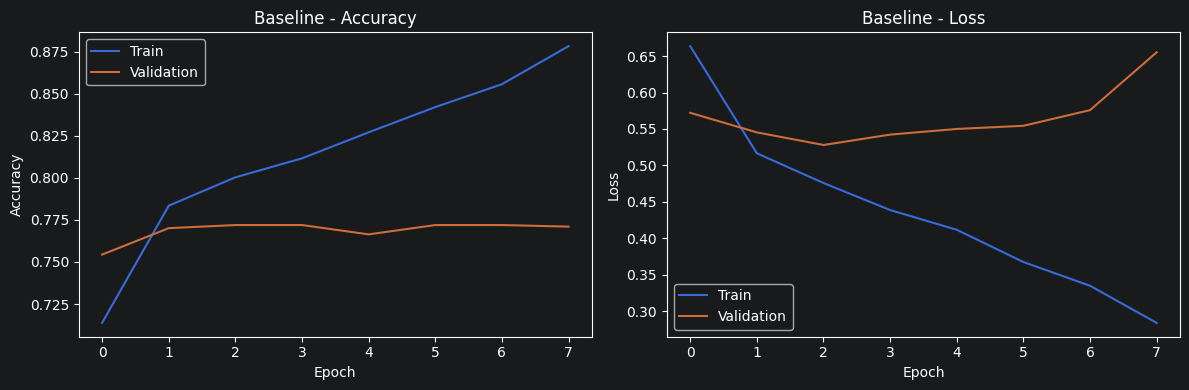

In [75]:
# Plot training and validation accuracy and loss over epochs
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Baseline - Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Baseline - Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig('results/plots/step1_training_history.png')
plt.show()

## Dataset Analysis (Class Distribution)

Training set class distribution:
  VIRAL: 1084 images
  BACTERIAL: 2087 images
  NORMAL: 1165 images


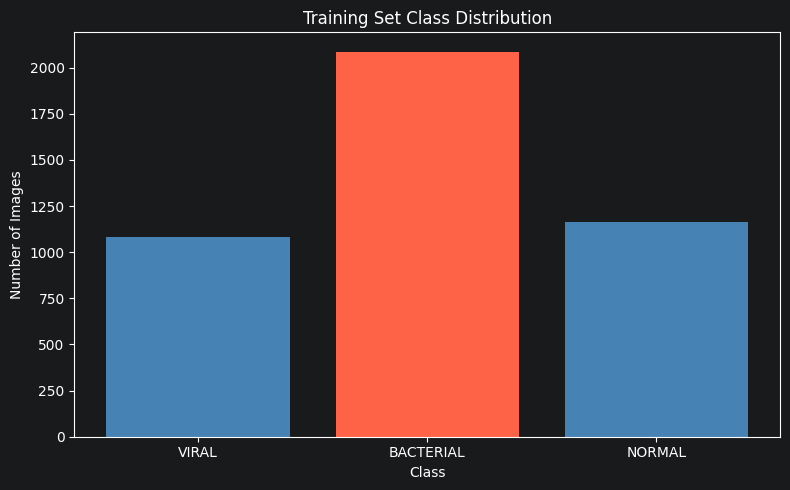

In [76]:
# Count the number of images per class in the training set
class_counts = {}
for images, labels in train_ds.unbatch():
    label = class_names[labels.numpy()]
    class_counts[label] = class_counts.get(label, 0) + 1

print("Training set class distribution:")
for class_name, count in class_counts.items():
    print(f"  {class_name}: {count} images")

# Plot class distribution
plt.figure(figsize=(8, 5))
plt.bar(class_counts.keys(), class_counts.values(), color=['steelblue', 'tomato'])
plt.title('Training Set Class Distribution')
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.tight_layout()
plt.savefig('results/plots/step2_class_distribution.png')
plt.show()

## Compute Class Weights

In [77]:
from sklearn.utils.class_weight import compute_class_weight

# Collect all labels from the training set
all_labels = []
for images, labels in train_ds.unbatch():
    all_labels.append(labels.numpy())

# Compute class weights to address class imbalance
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(all_labels),
    y=all_labels
)

class_weight_dict = dict(enumerate(class_weights))
print("Class weights:")
for i, weight in class_weight_dict.items():
    print(f"  {class_names[i]}: {weight:.4f}")

Class weights:
  BACTERIAL: 0.6925
  NORMAL: 1.2406
  VIRAL: 1.3333


## Improving Model by fixing Overfitting

In [78]:
# Improved model using GlobalAveragePooling2D instead of Flatten
# to reduce the number of parameters and combat overfitting
model_v2 = tf.keras.models.Sequential([
    tf.keras.Input(shape=(img_height, img_width, img_channels)),
    # Normalise pixel values from [0, 255] to [0, 1]
    Rescaling(1.0/255),
    # Convolutional layers for feature extraction
    Conv2D(16, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    # GlobalAveragePooling2D replaces Flatten - averages each feature map
    # into a single value, drastically reducing parameters
    tf.keras.layers.GlobalAveragePooling2D(),
    # Fully connected layers with increased dropout to reduce overfitting
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

model_v2.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=Adam(),
    metrics=['accuracy']
)

model_v2.summary()

Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_12 (Rescaling)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_36 (Conv2D)              │ (None, 126, 126, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_36 (MaxPooling2D) │ (None, 63, 63, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_37 (Conv2D)              │ (None, 61, 61, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_37 (MaxPooling2D) │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_38 (Conv2D)              │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_38 (MaxPooling2D) │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_7      │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,291 (126.14 KB)

 Trainable params: 32,291 (126.14 KB)

 Non-trainable params: 0 (0.00 B)

## Training the Improved Model

In [79]:
# Save the best improved model during training
save_callback_v2 = tf.keras.callbacks.ModelCheckpoint(
    'results/improved.keras',
    save_freq='epoch',
    save_best_only=True
)

# Early stopping to prevent overfitting
earlystop_callback = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5
)

start_time = time.time()

history_v2 = model_v2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    class_weight=class_weight_dict,
    callbacks=[save_callback_v2, earlystop_callback]
)

elapsed = time.time() - start_time
print(f'Training time: {elapsed/60:.1f} minutes')

Epoch 1/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.4460 - loss: 1.0262 - val_accuracy: 0.5817 - val_loss: 0.9178
Epoch 2/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6024 - loss: 0.8724 - val_accuracy: 0.6159 - val_loss: 0.8449
Epoch 3/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6169 - loss: 0.8099 - val_accuracy: 0.6454 - val_loss: 0.7930
Epoch 4/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6271 - loss: 0.7782 - val_accuracy: 0.6427 - val_loss: 0.7703
Epoch 5/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6497 - loss: 0.7517 - val_accuracy: 0.6741 - val_loss: 0.7439
Epoch 6/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6626 - loss: 0.7301 - val_accuracy: 0.6962 - val_loss: 0.7198
Epoch 7/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6944 - loss: 0.6894 - val_accuracy: 0.7202 - val_loss: 0.6806
Epoch 8/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6963 - loss: 0.6677 - val_accuracy: 0.7276 - v

## Evaluate Improved Model on Test Set

In [80]:
# Evaluate the improved model on the test set
score_v2 = model_v2.evaluate(test_ds)
print(f'Baseline Test Accuracy:  {score[1]*100:.2f}%')
print(f'Improved Test Accuracy:  {score_v2[1]*100:.2f}%')

37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7162 - loss: 0.6677
Baseline Test Accuracy:  76.43%
Improved Test Accuracy:  71.62%


## Plot Improved Model Training History

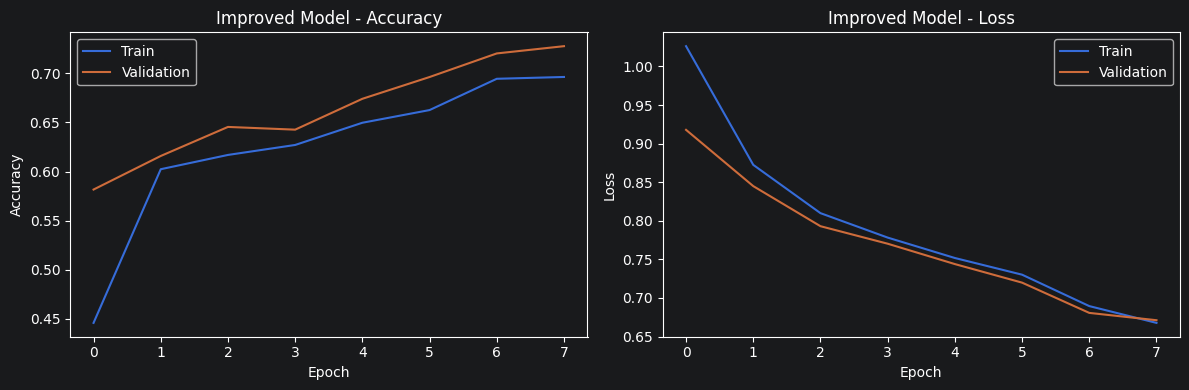

In [81]:
# Plot training and validation accuracy and loss for improved model
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_v2.history['accuracy'], label='Train')
plt.plot(history_v2.history['val_accuracy'], label='Validation')
plt.title('Improved Model - Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_v2.history['loss'], label='Train')
plt.plot(history_v2.history['val_loss'], label='Validation')
plt.title('Improved Model - Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig('results/plots/step3_improved_model.png')
plt.show()

## Data Augumentation

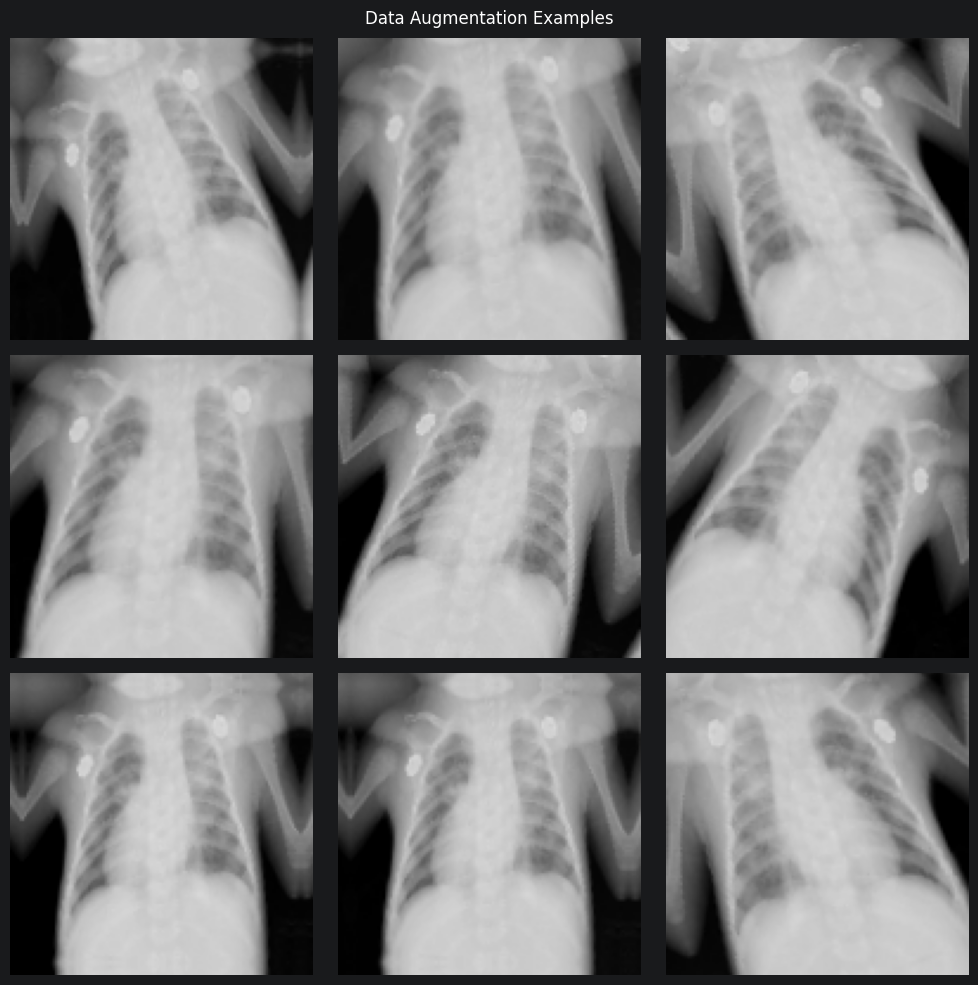

In [82]:
# Data augmentation layer - applies random transformations to training images
# to artificially increase the diversity of the training set
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1)
])

# Visualise the effect of augmentation on a single image
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    sample_image = images[0]
    for i in range(9):
        augmented = data_augmentation(tf.expand_dims(sample_image, 0))
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(augmented[0].numpy().astype('uint8'))
        plt.axis('off')
plt.suptitle('Data Augmentation Examples')
plt.tight_layout()
plt.savefig('results/plots/step4_augmentation.png')
plt.show()

## Model with Data Augmentation

In [83]:
# Build model with data augmentation built into the pipeline
model_v3 = tf.keras.models.Sequential([
    tf.keras.Input(shape=(img_height, img_width, img_channels)),
    # Data augmentation only applied during training
    data_augmentation,
    # Normalise pixel values from [0, 255] to [0, 1]
    Rescaling(1.0/255),
    # Convolutional layers for feature extraction
    Conv2D(16, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    # GlobalAveragePooling2D to reduce parameters
    tf.keras.layers.GlobalAveragePooling2D(),
    # Fully connected layers
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

model_v3.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=Adam(),
    metrics=['accuracy']
)

model_v3.summary()

Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_17 (Sequential)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_13 (Rescaling)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_39 (Conv2D)              │ (None, 126, 126, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_39 (MaxPooling2D) │ (None, 63, 63, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_40 (Conv2D)              │ (None, 61, 61, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_40 (MaxPooling2D) │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_41 (Conv2D)              │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_41 (MaxPooling2D) │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_8      │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,291 (126.14 KB)

 Trainable params: 32,291 (126.14 KB)

 Non-trainable params: 0 (0.00 B)

## Train Augmented Model

In [84]:
# Save the best augmented model during training
save_callback_v3 = tf.keras.callbacks.ModelCheckpoint(
    'results/augmented.keras',
    save_freq='epoch',
    save_best_only=True
)

# Early stopping to prevent overfitting
earlystop_callback_v3 = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5
)

start_time = time.time()

history_v3 = model_v3.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    class_weight=class_weight_dict,
    callbacks=[save_callback_v3, earlystop_callback_v3]
)

elapsed = time.time() - start_time
print(f'Training time: {elapsed/60:.1f} minutes')

Epoch 1/50
362/362 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.4373 - loss: 1.0510 - val_accuracy: 0.5882 - val_loss: 0.9825
Epoch 2/50
362/362 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.6289 - loss: 0.8707 - val_accuracy: 0.6547 - val_loss: 0.7979
Epoch 3/50
362/362 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.6594 - loss: 0.7910 - val_accuracy: 0.6251 - val_loss: 0.8098
Epoch 4/50
362/362 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.6815 - loss: 0.7638 - val_accuracy: 0.5974 - val_loss: 1.0000
Epoch 5/50
362/362 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.6810 - loss: 0.7491 - val_accuracy: 0.6574 - val_loss: 0.7383
Epoch 6/50
362/362 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.6711 - loss: 0.7588 - val_accuracy: 0.6556 - val_loss: 0.7230
Epoch 7/50
362/362 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.6771 - loss: 0.7560 - val_accuracy: 0.6685 - val_loss: 0.7206
Epoch 8/50
362/362 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.6737 - loss: 0.7381 - val_accu

## Evaluate Augmented Model

In [85]:
# Evaluate the augmented model on the test set
score_v3 = model_v3.evaluate(test_ds)
print(f'Baseline Test Accuracy:          {score[1]*100:.2f}%')
print(f'Improved Test Accuracy:          {score_v2[1]*100:.2f}%')
print(f'Augmented Model Test Accuracy:   {score_v3[1]*100:.2f}%')

37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7574 - loss: 0.5883
Baseline Test Accuracy:          76.43%
Improved Test Accuracy:          71.62%
Augmented Model Test Accuracy:   75.74%


## Transfer Learning with MobileNetV2

In [86]:
# Load MobileNetV2 pretrained on ImageNet, exclude the top classification layer
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(img_height, img_width, img_channels),
    include_top=False,
    weights='imagenet'
)

# Freeze the base model weights so they are not updated during training
base_model.trainable = False

# Build transfer learning model on top of MobileNetV2
model_v4 = tf.keras.models.Sequential([
    tf.keras.Input(shape=(img_height, img_width, img_channels)),
    # Data augmentation
    data_augmentation,
    # Normalise inputs to match MobileNetV2 expected range [-1, 1]
    tf.keras.layers.Lambda(lambda x: tf.keras.applications.mobilenet_v2.preprocess_input(x)),
    # Pretrained base model
    base_model,
    # Reduce feature maps to single values
    tf.keras.layers.GlobalAveragePooling2D(),
    # Classification head
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

model_v4.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=Adam(),
    metrics=['accuracy']
)

model_v4.summary()

Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_17 (Sequential)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_2 (Lambda)               │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_9      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,339 (9.24 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Train the Transfer Learning Model

In [87]:
# Save the best transfer learning model during training
save_callback_v4 = tf.keras.callbacks.ModelCheckpoint(
    'results/transfer.keras',
    save_freq='epoch',
    save_best_only=True
)

# Early stopping to prevent overfitting
earlystop_callback_v4 = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5
)

start_time = time.time()

history_v4 = model_v4.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    class_weight=class_weight_dict,
    callbacks=[save_callback_v4, earlystop_callback_v4]
)

elapsed = time.time() - start_time
print(f'Training time: {elapsed/60:.1f} minutes')

Epoch 1/50
362/362 ━━━━━━━━━━━━━━━━━━━━ 13s 33ms/step - accuracy: 0.6407 - loss: 0.7912 - val_accuracy: 0.6417 - val_loss: 0.8363
Epoch 2/50
362/362 ━━━━━━━━━━━━━━━━━━━━ 11s 30ms/step - accuracy: 0.6997 - loss: 0.6666 - val_accuracy: 0.6620 - val_loss: 0.8435
Epoch 3/50
362/362 ━━━━━━━━━━━━━━━━━━━━ 11s 30ms/step - accuracy: 0.7117 - loss: 0.6297 - val_accuracy: 0.7295 - val_loss: 0.6657
Epoch 4/50
362/362 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.7173 - loss: 0.6207 - val_accuracy: 0.7175 - val_loss: 0.6892
Epoch 5/50
362/362 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.7209 - loss: 0.6266 - val_accuracy: 0.6362 - val_loss: 0.9540
Epoch 6/50
362/362 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.7329 - loss: 0.6036 - val_accuracy: 0.7064 - val_loss: 0.7599
Epoch 7/50
362/362 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.7209 - loss: 0.5922 - val_accuracy: 0.7110 - val_loss: 0.6766
Epoch 8/50
362/362 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.7378 - loss: 0.5961 - 

## Fine Tuning MobileNetV2

In [88]:
# Unfreeze the last 20 layers of MobileNetV2 for fine tuning
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

# Recompile with a lower learning rate to avoid destroying pretrained weights
model_v4.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=Adam(learning_rate=1e-5),
    metrics=['accuracy']
)

print(f'Trainable layers: {sum([1 for l in base_model.layers if l.trainable])}')
model_v4.summary()

Trainable layers: 20


Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_17 (Sequential)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_2 (Lambda)               │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_9      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,339 (9.24 MB)

 Trainable params: 1,370,435 (5.23 MB)

 Non-trainable params: 1,051,904 (4.01 MB)

## Train Fine-Tuned Model

In [89]:
# Save the best fine tuned model during training
save_callback_v4_ft = tf.keras.callbacks.ModelCheckpoint(
    'results/transfer_finetuned.keras',
    save_freq='epoch',
    save_best_only=True
)

# Early stopping
earlystop_callback_v4_ft = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5
)

start_time = time.time()

history_v4_ft = model_v4.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    class_weight=class_weight_dict,
    callbacks=[save_callback_v4_ft, earlystop_callback_v4_ft]
)

elapsed = time.time() - start_time
print(f'Training time: {elapsed/60:.1f} minutes')

Epoch 1/50
362/362 ━━━━━━━━━━━━━━━━━━━━ 15s 34ms/step - accuracy: 0.6651 - loss: 0.7123 - val_accuracy: 0.7387 - val_loss: 0.6346
Epoch 2/50
362/362 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step - accuracy: 0.7064 - loss: 0.6679 - val_accuracy: 0.7221 - val_loss: 0.6659
Epoch 3/50
362/362 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step - accuracy: 0.7239 - loss: 0.6214 - val_accuracy: 0.7442 - val_loss: 0.6219
Epoch 4/50
362/362 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step - accuracy: 0.7380 - loss: 0.6224 - val_accuracy: 0.7184 - val_loss: 0.7127
Epoch 5/50
362/362 ━━━━━━━━━━━━━━━━━━━━ 12s 32ms/step - accuracy: 0.7357 - loss: 0.6161 - val_accuracy: 0.7331 - val_loss: 0.6603
Epoch 6/50
362/362 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step - accuracy: 0.7449 - loss: 0.5950 - val_accuracy: 0.7424 - val_loss: 0.6485
Epoch 7/50
362/362 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step - accuracy: 0.7488 - loss: 0.5730 - val_accuracy: 0.7470 - val_loss: 0.6644
Epoch 8/50
362/362 ━━━━━━━━━━━━━━━━━━━━ 12s 32ms/step - accuracy: 0.7493 - loss: 0.5831 - 

## Evaluate All Models on Test Set

In [90]:
# Evaluate fine tuned model on test set
score_v4_ft = model_v4.evaluate(test_ds)

# Final comparison of all models
print('\n Final Model Comparison')
print(f'Baseline:              75.51%')
print(f'Improved (GAP):        70.48%')
print(f'Augmented:             75.51%')
print(f'Transfer Learning:     {score_v4_ft[1]*100:.2f}%')

37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.7620 - loss: 0.6627

 Final Model Comparison
Baseline:              75.51%
Improved (GAP):        70.48%
Augmented:             75.51%
Transfer Learning:     76.20%
